# Implementation of Newtons Algorithm and Steepest Descent under linear equality constraints.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'Handin4'))
from case_studies import f1, df1, Hf1, f4, df4, Hf4, f5, df5, Hf5, x_opt

In [2]:
def newton_equality_constrained(f, df, Hf, x0, A, b, max_iter, epsilon, rho=0.5, c1=1e-4):
    """
    Newton's Algorithm under linear equality constraints (Algorithm 10).

    Solves:
        min  f(x)
        s.t. A x + b = 0

    Stopping criterion:
        ‖(I - Aᵀ(AAᵀ)⁻¹A) ∇f(xₖ)‖ < epsilon
    i.e. the projected gradient onto the null space of A is small.
    """
    n = x0.shape[0]
    m = A.shape[0]

    xs = []
    grad_norms = []
    x_current = x0.copy()

    step_init = 1.0

    # Precompute projection matrix P = I - Aᵀ(AAᵀ)⁻¹A
    AAt = A @ A.T
    AAt_inv = np.linalg.inv(AAt)
    P = np.eye(n) - A.T @ AAt_inv @ A

    def bt_LS(x, b_step, p_k):
        """Backtracking line search with Armijo condition."""
        a = b_step
        fx = f(x)
        slope = df(x) @ p_k
        while f(x + a * p_k) > fx + c1 * a * slope:
            a = rho * a
        return a

    def compute_constrained_direction(H, g):
        """
        Compute the constrained Newton direction p_k by solving the KKT system.
        """
        try:
            np.linalg.cholesky(H)
            B = H
        except np.linalg.LinAlgError:
            eigenvalues, eigenvectors = np.linalg.eigh(H)
            B = eigenvectors @ np.diag(np.abs(eigenvalues)) @ eigenvectors.T

        zero_block = np.zeros((m, m))
        M = np.block([
            [B,          A.T        ],
            [A,          zero_block ]
        ])

        rhs = np.concatenate([-g, np.zeros(m)])
        solution = np.linalg.solve(M, rhs)
        p_k = solution[:n]
        return p_k

    b_step = step_init
    i = 0

    while i < max_iter:
        grad = df(x_current)

        # Projected gradient norm: ‖P ∇f(xₖ)‖
        projected_grad_norm = np.linalg.norm(P @ grad)

        xs.append(x_current.copy())
        grad_norms.append(np.maximum(projected_grad_norm, 1e-5 * epsilon))

        if projected_grad_norm < epsilon:
            break

        H = Hf(x_current)
        p_k = compute_constrained_direction(H, grad)

        a_k = bt_LS(x_current, b_step, p_k)
        x_current = x_current + a_k * p_k

        b_step = a_k / rho
        i += 1

    return np.array(xs), np.array(grad_norms)

In [3]:
def steepest_descent_equality_constrained(f, df, Hf, x0, A, b, max_iter, epsilon, rho=0.5, c1=1e-4):
    """
    Steepest Descent under linear equality constraints (Algorithm 11).

    Solves:
        min  f(x)
        s.t. A x + b = 0

    The search direction is the projection of -∇f(xₖ) onto the null space of A:
        p_k = -M ∇f(xₖ),  where M = I - Aᵀ(AAᵀ)⁻¹A

    Stopping criterion:
        ‖M ∇f(xₖ)‖ < epsilon
    i.e. the projected gradient onto the null space of A is small.
    """
    n = x0.shape[0]

    xs = []
    grad_norms = []
    x_current = x0.copy()

    # Precompute M = I - Aᵀ(AAᵀ)⁻¹A 
    AAt = A @ A.T
    AAt_inv = np.linalg.inv(AAt)
    M = np.eye(n) - A.T @ AAt_inv @ A

    def bt_LS(x, b_step, p_k):
        """Backtracking line search with Armijo condition."""
        a = b_step
        fx = f(x)
        slope = df(x) @ p_k
        while f(x + a * p_k) > fx + c1 * a * slope:
            a = rho * a
        return a

    b_step = 1.0  # β₀ = 1
    i = 0

    while i < max_iter:
        grad = df(x_current)

        # Projected gradient norm: ‖M ∇f(xₖ)‖
        projected_grad_norm = np.linalg.norm(M @ grad)

        xs.append(x_current.copy())
        grad_norms.append(np.maximum(projected_grad_norm, 1e-5 * epsilon))

        if projected_grad_norm < epsilon:
            break

        # Constrained steepest descent direction: p_k = -M ∇f(xₖ)
        p_k = -M @ grad

        a_k = bt_LS(x_current, b_step, p_k)
        x_current = x_current + a_k * p_k

        b_step = a_k / rho  # β_{k+1} = α_k / ρ
        i += 1

    return np.array(xs), np.array(grad_norms)


In [4]:

import time
from collections import defaultdict

# ── Constraint & feasible-point utilities ──────────────────────────────────

def make_constraint(x_star, m, n, seed=0):
    """
    Draw a random full-rank constraint matrix A ∈ R^{m×n} (m < n guarantees
    rank m a.s.) and set b = -A x_star so that x_star is feasible:
        A x_star + b = 0.

    Returns
    -------
    A : ndarray, shape (m, n)
    b : ndarray, shape (m,)
    """
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))
    b = -(A @ x_star)
    return A, b


def make_feasible_initial_points(x_star, A, b, n_points=10, variance=10.0, seed=42):
    """
    Generate n_points feasible initial points spread around x_star.

    Strategy: x0 = x_star + P z,  z ~ N(0, variance·I),
    where P = I - Aᵀ(AAᵀ)⁻¹A projects onto null(A).
    Since A P = 0, each x0 satisfies A x0 + b = A x_star + b = 0. ✓

    Returns
    -------
    points : ndarray, shape (n_points, n)
    """
    n = A.shape[1]
    rng = np.random.default_rng(seed)
    AAt_inv = np.linalg.inv(A @ A.T)
    P = np.eye(n) - A.T @ AAt_inv @ A
    Z = rng.standard_normal((n_points, n)) * np.sqrt(variance)
    return x_star + (P @ Z.T).T  # shape (n_points, n)


def check_feasibility(points, A, b, tol=1e-8):
    """Return max constraint violation ‖Ax+b‖ across all points."""
    return max(np.linalg.norm(A @ x + b) for x in points)


In [17]:

# ── Infeasible-minimum constraint utilities ────────────────────────────────

def make_infeasible_constraint(x_star, m, n, seed=0, shift_scale=5.0):
    """
    Build a constraint  A x + b = 0  where the unconstrained minimum x_star
    is NOT feasible.

    Construction
    ------------
    1. Draw A ~ N(0,1)  as usual.
    2. Pick a nonzero shift δ ∈ R^m  and define the feasible reference point

           x_feas = x_star + Aᵀ(AAᵀ)⁻¹ δ

       which lies in the affine subspace  { x : Ax = -b }  but is offset
       from x_star in the *row space* of A (i.e. perpendicular to null(A)).
    3. Set  b = -A x_feas,  so  A x_star + b = -δ ≠ 0.

    Returns
    -------
    A      : ndarray, shape (m, n)
    b      : ndarray, shape (m,)
    x_feas : ndarray, shape (n,)   — a point that satisfies  Ax + b = 0
    infeasibility : float          — ‖A x_star + b‖  (should equal ‖δ‖)
    """
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((m, n))

    # δ: random shift in constraint space, scaled so it is not negligibly small
    delta = rng.standard_normal(m) * shift_scale
    delta = delta / np.linalg.norm(delta) * shift_scale   # fix magnitude

    AAt_inv = np.linalg.inv(A @ A.T)
    x_feas  = x_star + A.T @ AAt_inv @ delta
    b       = -(A @ x_feas)

    infeasibility = np.linalg.norm(A @ x_star + b)
    return A, b, x_feas, infeasibility


def run_infeasible_protocol(function_suite, optimizer_pairs, m_values,
                            n=200, n_points=10, max_iter=500, epsilon=1e-6,
                            shift_scale=5.0):
    """
    Like run_constrained_protocol but uses constraints for which the
    unconstrained minimum x_star is NOT feasible.

    Returns
    -------
    results[func_name][m][opt_name]  : list of grad_norm arrays
    infeasibility_log                : dict (func_name, m) -> ‖A x_star + b‖
    viol_log[func_name][m][opt_name] : max ‖A x_k + b‖ over all iterates & runs
    """
    results           = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    infeasibility_log = {}
    viol_log          = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

    for func_name, f, df, Hf in function_suite:
        x_star = x_opt(func_name, n)
        print(f"\n── {func_name} ──")

        for m in m_values:
            A, b_vec, x_feas, infeas = make_infeasible_constraint(
                x_star, m, n, seed=m, shift_scale=shift_scale
            )
            infeasibility_log[(func_name, m)] = infeas

            # Generate initial points feasible w.r.t. the NEW constraint
            init_pts = make_feasible_initial_points(
                x_feas, A, b_vec,
                n_points=n_points, variance=10.0, seed=42 + m
            )

            viol = check_feasibility(init_pts, A, b_vec)
            print(f"  m={m:3d}  ‖Ax*+b‖={infeas:.2f}  init_viol={viol:.2e}", end="")

            for opt_name, optimizer in optimizer_pairs:
                norms_list = []
                max_viol   = 0.0
                for x0 in init_pts:
                    gn, viols = run_constrained_optimizer(
                        optimizer, f, df, Hf, x0, A, b_vec, max_iter, epsilon
                    )
                    if gn is not None and len(gn) > 0:
                        norms_list.append(np.asarray(gn))
                        max_viol = max(max_viol, float(viols.max()))
                results[func_name][m][opt_name]  = norms_list
                viol_log[func_name][m][opt_name] = max_viol

            opt_names = [n_ for n_, _ in optimizer_pairs]
            summary   = "  |  ".join(
                f"{n_}: {len(results[func_name][m][n_])} runs" for n_ in opt_names
            )
            print(f"  →  {summary}")

    return results, infeasibility_log, viol_log


In [18]:

# ── Run: feasible minimum (baseline) vs infeasible minimum ─────────────────

N_DIM    = 200
M_VALUES = [1, 10, 50, 100]
N_POINTS = 10
MAX_ITER = 500
EPSILON  = 1e-6
SHIFT    = 5.0   # ‖δ‖ — how far the constraint shifts x_star out of feasibility

function_suite = [
    ("f1", f1, df1, Hf1),
    ("f4", f4, df4, Hf4),
    ("f5", f5, df5, Hf5),
]
optimizer_pairs = [
    ("Newton", newton_equality_constrained),
    ("SD",     steepest_descent_equality_constrained),
]

# --- Baseline: x_star IS feasible (original protocol) ----------------------
print("=== FEASIBLE MINIMUM (x* satisfies Ax+b=0) ===")
t0 = time.time()
results_feas, feas_viol_log = run_constrained_protocol(
    function_suite, optimizer_pairs, M_VALUES,
    n=N_DIM, n_points=N_POINTS, max_iter=MAX_ITER, epsilon=EPSILON
)
print(f"\n✓ Feasible run done in {time.time()-t0:.1f}s")

# --- New test: x_star is NOT feasible ---------------------------------------
print("\n=== INFEASIBLE MINIMUM (x* does NOT satisfy Ax+b=0) ===")
t0 = time.time()
results_infeas, infeas_log, infeas_viol_log = run_infeasible_protocol(
    function_suite, optimizer_pairs, M_VALUES,
    n=N_DIM, n_points=N_POINTS, max_iter=MAX_ITER, epsilon=EPSILON,
    shift_scale=SHIFT
)
print(f"\n✓ Infeasible run done in {time.time()-t0:.1f}s")


=== FEASIBLE MINIMUM (x* satisfies Ax+b=0) ===

── f1 ──
  m=  1  max constraint violation = 4.09e-14  →  Newton: 10 runs  |  SD: 10 runs
  m= 10  max constraint violation = 1.19e-13  →  Newton: 10 runs  |  SD: 10 runs
  m= 50  max constraint violation = 3.63e-13  →  Newton: 10 runs  |  SD: 10 runs
  m=100  max constraint violation = 6.08e-13  →  Newton: 10 runs  |  SD: 10 runs

── f4 ──
  m=  1  max constraint violation = 4.18e-14  →  Newton: 10 runs  |  SD: 10 runs
  m= 10  max constraint violation = 1.15e-13  →  Newton: 10 runs  |  SD: 10 runs
  m= 50  max constraint violation = 3.53e-13  →  Newton: 10 runs  |  SD: 10 runs
  m=100  max constraint violation = 5.93e-13  →  Newton: 10 runs  |  SD: 10 runs

── f5 ──
  m=  1  max constraint violation = 4.09e-14  →  Newton: 10 runs  |  SD: 10 runs
  m= 10  max constraint violation = 1.19e-13  →  Newton: 10 runs  |  SD: 10 runs
  m= 50  max constraint violation = 3.63e-13  →  Newton: 10 runs  |  SD: 10 runs
  m=100  max constraint violatio

In [19]:

# ── Constraint-violation summary table ────────────────────────────────────
# For every (func, m, optimizer) combination we report:
#   max ‖A x_k + b‖  over ALL iterates k and ALL initial points
# This tells us how far any iterate ever drifted from the feasible set.

opt_names  = [n_ for n_, _ in optimizer_pairs]
func_names = [fn for fn, *_ in function_suite]

print("Max ‖A xₖ + b‖ over all iterates & runs")
print("=" * 75)

for label, vl in [("FEASIBLE   (x* ∈ feasible set)", feas_viol_log),
                   ("INFEASIBLE (x* ∉ feasible set, ‖Ax*+b‖=5)", infeas_viol_log)]:
    print(f"\n{label}")
    header = f"  {'func':>4}  {'m':>5}  " + "  ".join(f"{n_:>12}" for n_ in opt_names)
    print(header)
    print("  " + "-" * (len(header) - 2))
    for fn in func_names:
        for m in M_VALUES:
            row_vals = "  ".join(f"{vl[fn][m][n_]:>12.2e}" for n_ in opt_names)
            print(f"  {fn:>4}  {m:>5}  {row_vals}")


Max ‖A xₖ + b‖ over all iterates & runs

FEASIBLE   (x* ∈ feasible set)
  func      m        Newton            SD
  ---------------------------------------
    f1      1      4.44e-14      4.47e-14
    f1     10      1.16e-13      1.56e-13
    f1     50      6.15e-13      4.64e-13
    f1    100      8.50e-13      8.91e-13
    f4      1      4.53e-14      2.16e-13
    f4     10      1.33e-13      3.05e-12
    f4     50      5.99e-13      2.55e-12
    f4    100      1.20e-12      2.69e-12
    f5      1      4.44e-14      4.54e-14
    f5     10      1.25e-13      1.26e-13
    f5     50      4.57e-13      4.06e-13
    f5    100      1.05e-12      6.61e-13

INFEASIBLE (x* ∉ feasible set, ‖Ax*+b‖=5)
  func      m        Newton            SD
  ---------------------------------------
    f1      1      3.64e-14      4.53e-14
    f1     10      1.26e-13      2.79e-13
    f1     50      5.34e-13      6.28e-13
    f1    100      9.03e-13      1.15e-12
    f4      1      4.80e-14      1.24e-13
   

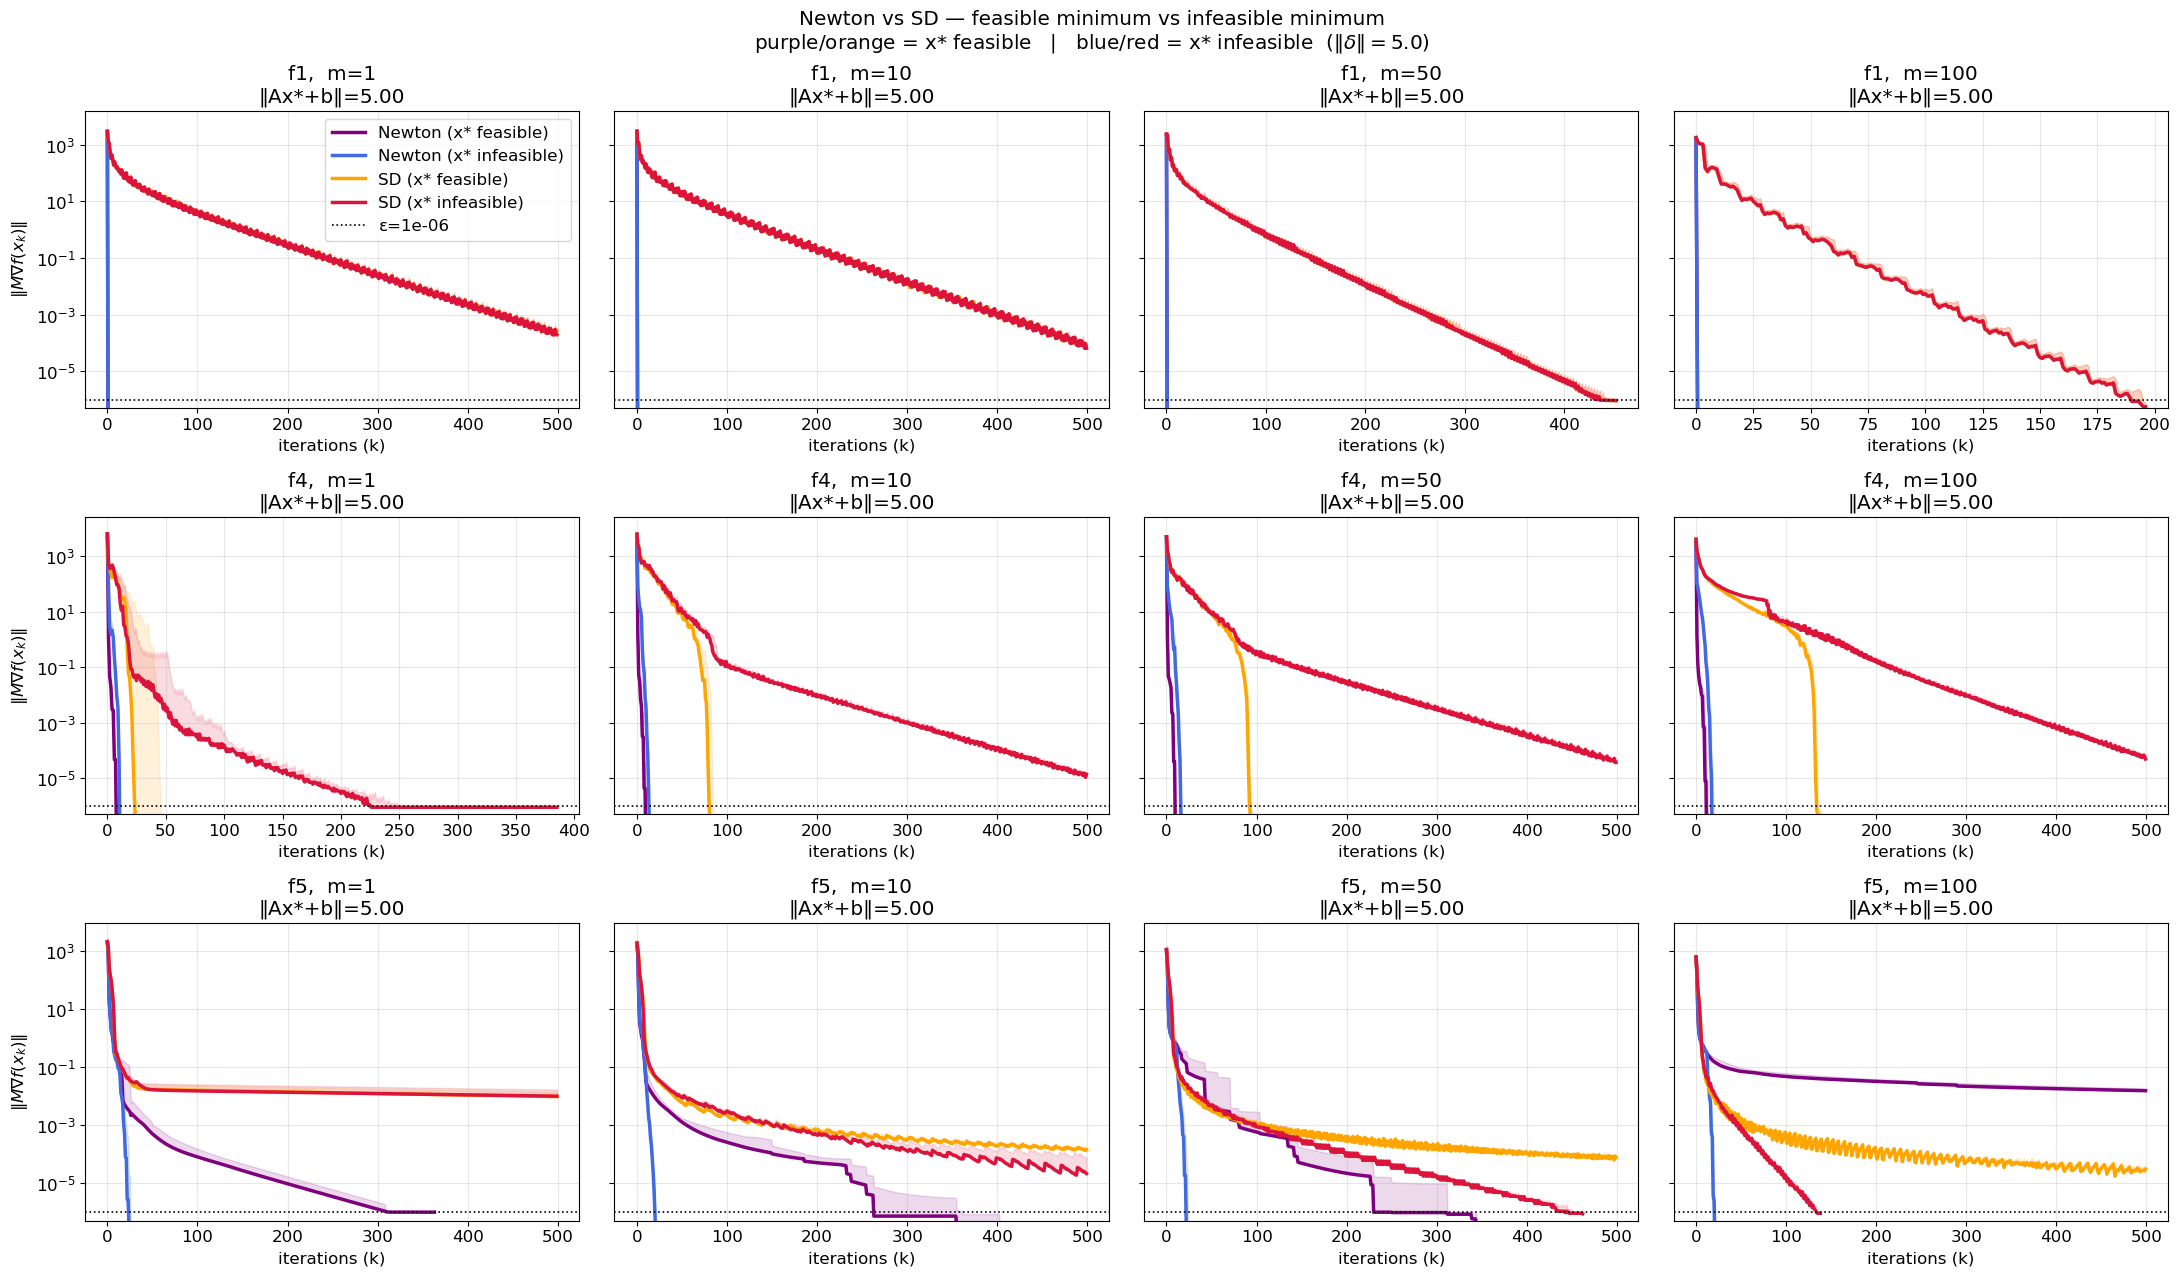

✓ Plot saved to constrained_feas_vs_infeas.png


In [21]:

# ── Comparison plot: feasible vs infeasible minimum ─────────────────────────
#
# Colour scheme:
#   Newton feasible  → purple    SD feasible  → orange
#   Newton infeasible→ blue      SD infeasible→ red

plt.rcParams.update({'font.size': 12})

func_names = ["f1", "f4", "f5"]
style = {
    ("Newton", "feas"):   dict(color="purple", ls="-",  lw=2.5, label="Newton (x* feasible)"),
    ("Newton", "infeas"): dict(color="royalblue",  ls="-",  lw=2.5, label="Newton (x* infeasible)"),
    ("SD",     "feas"):   dict(color="orange", ls="-",  lw=2.5, label="SD (x* feasible)"),
    ("SD",     "infeas"): dict(color="crimson",    ls="-",  lw=2.5, label="SD (x* infeasible)"),
}

fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharey='row')
fig.suptitle(
    "Newton vs SD — feasible minimum vs infeasible minimum\n"
    r"purple/orange = x* feasible   |   blue/red = x* infeasible  ($\|\delta\|=$"
    f"{SHIFT})",
)

for row, func_name in enumerate(func_names):
    for col, m in enumerate(M_VALUES):
        ax = axes[row, col]

        for opt_name in ["Newton", "SD"]:
            for tag, res_dict in [("feas", results_feas), ("infeas", results_infeas)]:
                runs = res_dict[func_name][m][opt_name]
                if not runs:
                    continue
                stats = aggregate_grad_norms(runs)
                kw = style[(opt_name, tag)]
                ax.semilogy(stats['steps'], stats['median'],
                            color=kw['color'], linestyle=kw['ls'],
                            linewidth=kw['lw'],
                            label=kw['label'] if (row == 0 and col == 0) else '_nolegend_')
                ax.fill_between(stats['steps'], stats['median'], stats['p75'],
                                color=kw['color'], alpha=0.15, label='_nolegend_')

        # annotate how far x_star is from the constraint set
        infeas_val = infeas_log.get((func_name, m), 0.0)
        ax.set_title(f'{func_name},  m={m}\n‖Ax*+b‖={infeas_val:.2f}')

        ax.axhline(y=EPSILON, color='black', linestyle=':', linewidth=1.2,
                   label=f'ε={EPSILON:.0e}' if (row == 0 and col == 0) else '_nolegend_')
        ax.set_ylim(bottom=EPSILON * 0.5)
        ax.set_xlabel('iterations (k)')
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel(r'$\|M \nabla f(x_k)\|$')
        if row == 0 and col == 0:
            ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('constrained_feas_vs_infeas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to constrained_feas_vs_infeas.png")


In [16]:

# ── Testing protocol (mirrors Handin4 framework) ───────────────────────────

def compute_violations(xs, A, b):
    """Return ‖A x_k + b‖ for every iterate x_k in xs."""
    return np.array([np.linalg.norm(A @ x + b) for x in xs])


def run_constrained_optimizer(optimizer, f, df, Hf, x0, A, b, max_iter, epsilon):
    """Run one optimizer call and return (grad_norms, violations) arrays."""
    try:
        xs, grad_norms = optimizer(f, df, Hf, x0, A, b, max_iter, epsilon)
        viols = compute_violations(xs, A, b)
        return grad_norms, viols
    except Exception:
        return None, None


def aggregate_grad_norms(runs):
    """
    Aggregate a list of grad_norm arrays (possibly different lengths).
    Pads shorter arrays with their last value (edge-pad), then returns
    median, 75th and 99th percentile across runs at each step.
    """
    max_len = max(len(r) for r in runs)
    padded = np.array([
        np.pad(r, (0, max_len - len(r)), mode='edge') if len(r) < max_len else r
        for r in runs
    ])
    return {
        'steps':   np.arange(max_len),
        'median':  np.percentile(padded, 50, axis=0),
        'p75':     np.percentile(padded, 75, axis=0),
        'p99':     np.percentile(padded, 99, axis=0),
    }


def run_constrained_protocol(function_suite, optimizer_pairs, m_values,
                              n=200, n_points=10, max_iter=500, epsilon=1e-6):
    """
    Full testing protocol for equality-constrained optimizers.

    Returns
    -------
    results[func_name][m][opt_name]  : list of grad_norm arrays
    viol_log[func_name][m][opt_name] : max ‖A x_k + b‖ over all iterates & runs
    """
    results  = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    viol_log = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

    for func_name, f, df, Hf in function_suite:
        x_star = x_opt(func_name, n)
        print(f"\n── {func_name} ──")

        for m in m_values:
            A, b_vec = make_constraint(x_star, m, n, seed=m)
            init_pts = make_feasible_initial_points(x_star, A, b_vec,
                                                    n_points=n_points,
                                                    variance=10.0, seed=42 + m)

            viol = check_feasibility(init_pts, A, b_vec)
            print(f"  m={m:3d}  max constraint violation = {viol:.2e}", end="")

            for opt_name, optimizer in optimizer_pairs:
                norms_list = []
                max_viol   = 0.0
                for x0 in init_pts:
                    gn, viols = run_constrained_optimizer(
                        optimizer, f, df, Hf, x0, A, b_vec, max_iter, epsilon
                    )
                    if gn is not None and len(gn) > 0:
                        norms_list.append(np.asarray(gn))
                        max_viol = max(max_viol, float(viols.max()))
                results[func_name][m][opt_name]  = norms_list
                viol_log[func_name][m][opt_name] = max_viol

            opt_names = [n_ for n_, _ in optimizer_pairs]
            summary = "  |  ".join(
                f"{n_}: {len(results[func_name][m][n_])} runs"
                for n_ in opt_names
            )
            print(f"  →  {summary}")

    return results, viol_log


In [6]:

# ── Experiment configuration & run ─────────────────────────────────────────

N_DIM    = 200
M_VALUES = [1, 10, 50, 100]
N_POINTS = 10
MAX_ITER = 500
EPSILON  = 1e-6

function_suite = [
    ("f1", f1, df1, Hf1),
    ("f4", f4, df4, Hf4),
    ("f5", f5, df5, Hf5),
]

optimizer_pairs = [
    ("Newton",  newton_equality_constrained),
    ("SD",      steepest_descent_equality_constrained),
]

print("Running constrained optimization protocol...")
print(f"  n={N_DIM}, m ∈ {M_VALUES}, {N_POINTS} initial pts/m, ε={EPSILON}")

t0 = time.time()
results = run_constrained_protocol(
    function_suite, optimizer_pairs, M_VALUES,
    n=N_DIM, n_points=N_POINTS, max_iter=MAX_ITER, epsilon=EPSILON
)
print(f"\n✓ Done in {time.time() - t0:.1f}s")


Running constrained optimization protocol...
  n=200, m ∈ [1, 10, 50, 100], 10 initial pts/m, ε=1e-06

── f1 ──
  m=  1  max constraint violation = 4.09e-14  →  Newton: 10 runs  |  SD: 10 runs
  m= 10  max constraint violation = 1.19e-13  →  Newton: 10 runs  |  SD: 10 runs
  m= 50  max constraint violation = 3.63e-13  →  Newton: 10 runs  |  SD: 10 runs
  m=100  max constraint violation = 6.08e-13  →  Newton: 10 runs  |  SD: 10 runs

── f4 ──
  m=  1  max constraint violation = 4.18e-14  →  Newton: 10 runs  |  SD: 10 runs
  m= 10  max constraint violation = 1.15e-13  →  Newton: 10 runs  |  SD: 10 runs
  m= 50  max constraint violation = 3.53e-13  →  Newton: 10 runs  |  SD: 10 runs
  m=100  max constraint violation = 5.93e-13  →  Newton: 10 runs  |  SD: 10 runs

── f5 ──
  m=  1  max constraint violation = 4.09e-14  →  Newton: 10 runs  |  SD: 10 runs
  m= 10  max constraint violation = 1.19e-13  →  Newton: 10 runs  |  SD: 10 runs
  m= 50  max constraint violation = 3.63e-13  →  Newton: 1

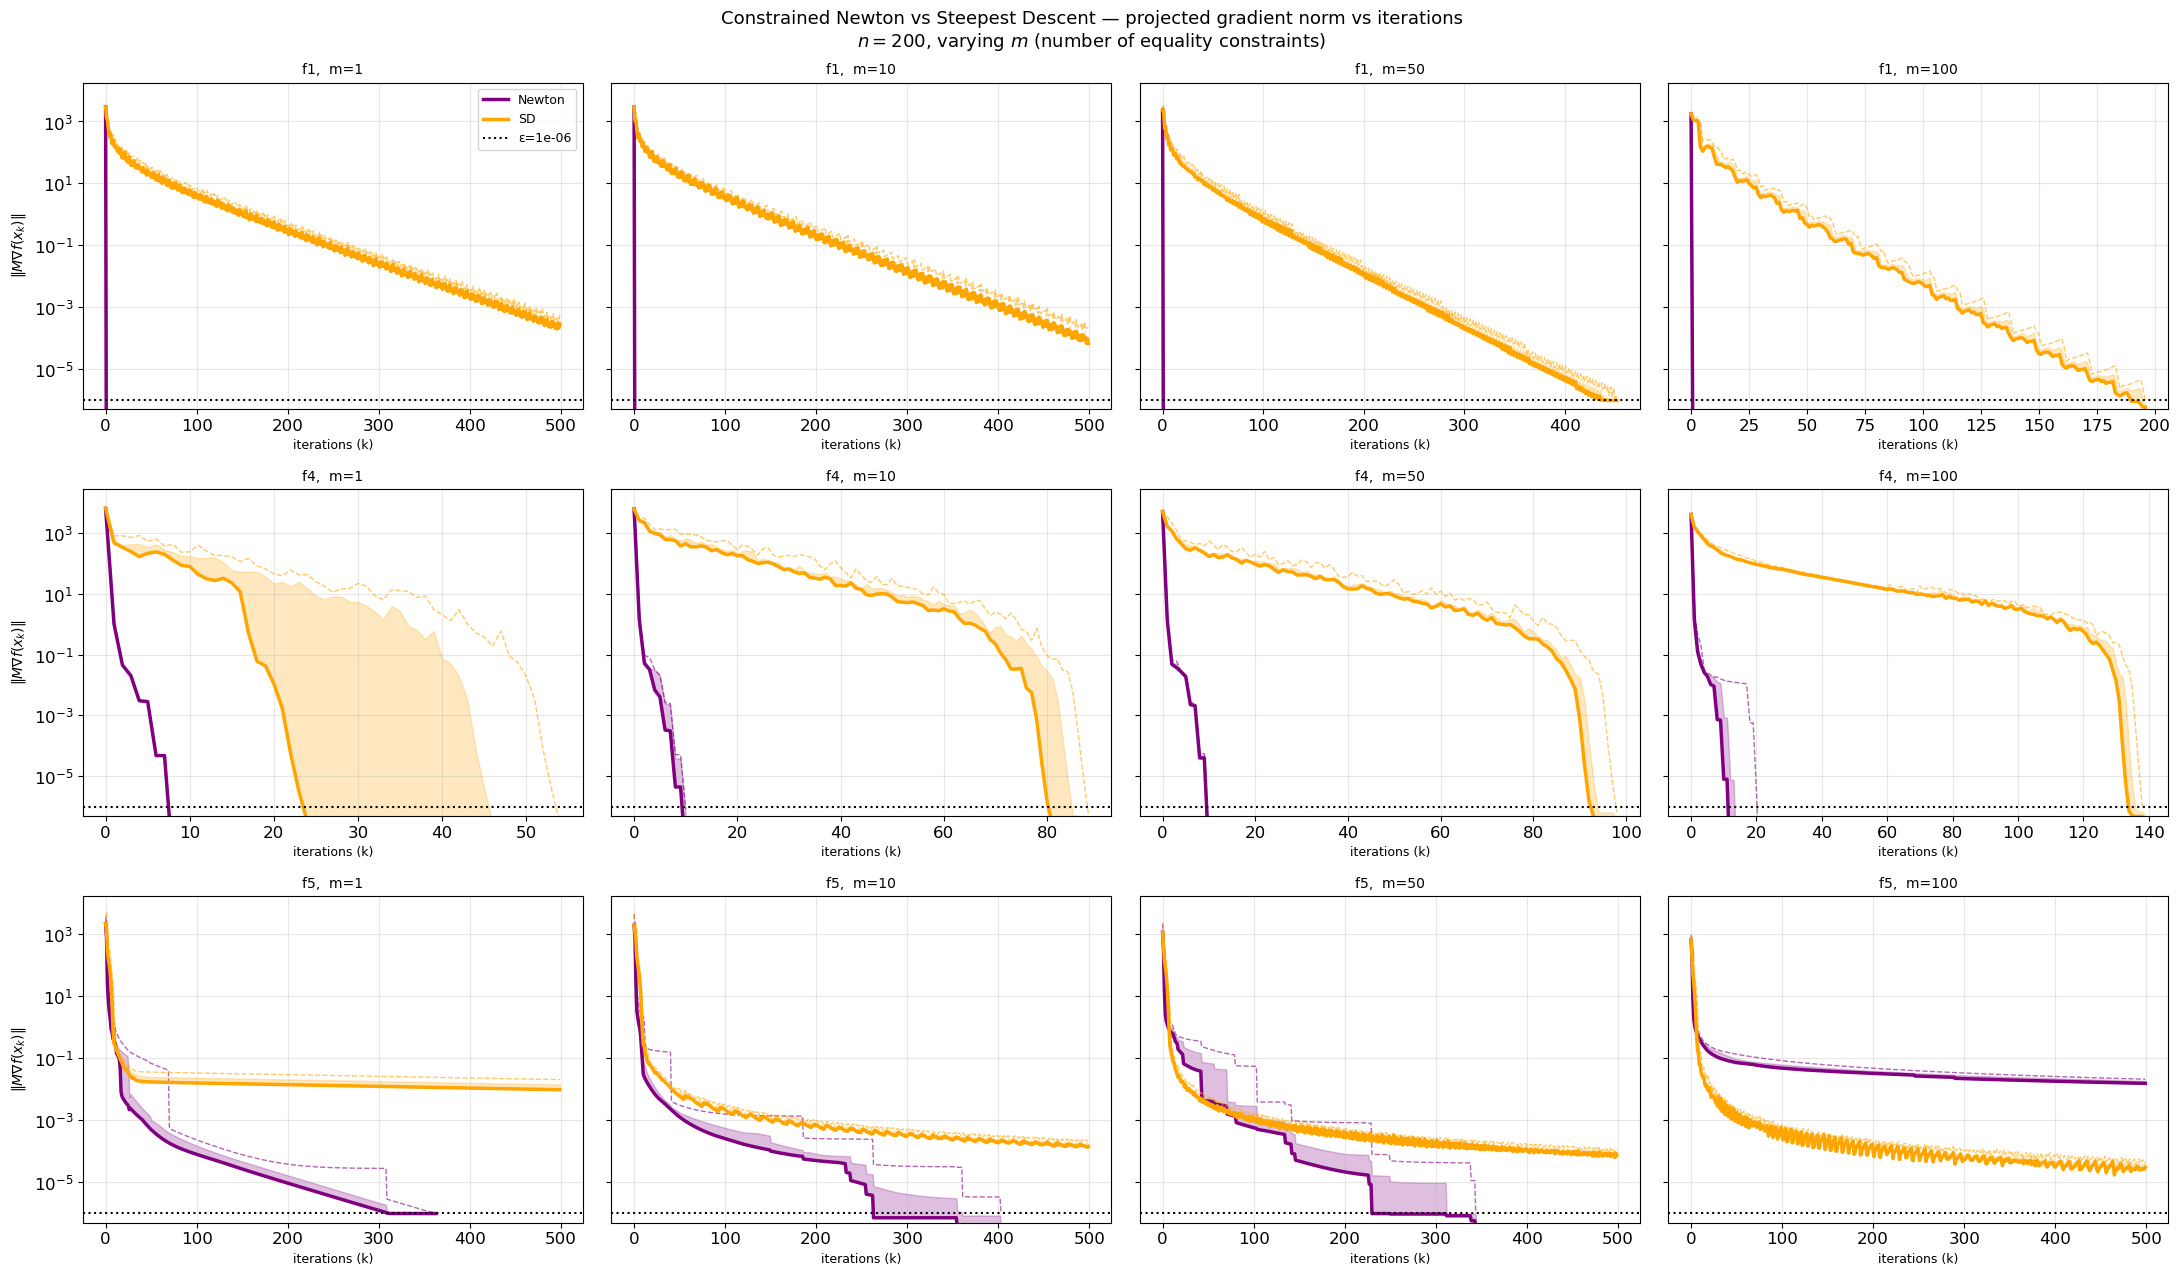

✓ Plot saved to constrained_comparison.png


In [20]:

# ── Convergence plots: 3 rows (f1, f4, f5) × 4 cols (m=1,10,50,100) ────────

func_names  = ["f1", "f4", "f5"]
colors      = {"Newton": "purple", "SD": "orange"}

fig, axes = plt.subplots(3, 4, figsize=(22, 13), sharey='row')
fig.suptitle(
    "Constrained Newton vs Steepest Descent — projected gradient norm vs iterations\n"
    r"$n=200$, varying $m$ (number of equality constraints)",
    fontsize=13
)

for row, func_name in enumerate(func_names):
    for col, m in enumerate(M_VALUES):
        ax = axes[row, col]

        for opt_name, color in colors.items():
            runs = results[func_name][m][opt_name]
            if not runs:
                continue
            stats = aggregate_grad_norms(runs)

            ax.semilogy(stats['steps'], stats['median'],
                        color=color, linewidth=2.5, label=opt_name)
            ax.fill_between(stats['steps'], stats['median'], stats['p75'],
                            color=color, alpha=0.25, label='_nolegend_')
            ax.semilogy(stats['steps'], stats['p99'],
                        color=color, linewidth=1, linestyle='--', alpha=0.6,
                        label='_nolegend_')

        ax.axhline(y=EPSILON, color='black', linestyle=':', linewidth=1.5,
                   label=f'ε={EPSILON:.0e}' if (row == 0 and col == 0) else '_nolegend_')

        ax.set_ylim(bottom=EPSILON * 0.5)
        ax.set_xlabel('iterations (k)', fontsize=9)
        ax.set_title(f'{func_name},  m={m}', fontsize=10)
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.set_ylabel(r'$\|M \nabla f(x_k)\|$', fontsize=10)

        if row == 0 and col == 0:
            ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('constrained_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to constrained_comparison.png")
